In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [7]:
df = pd.read_csv("customer.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['TotalCharges'].dtype

dtype('O')

In [13]:
#convert it into numeric 
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

/var/folders/q5/pld9cb2s1wd0pnqnx2xl_6400000gn/T/ipykernel_9961/3929950690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


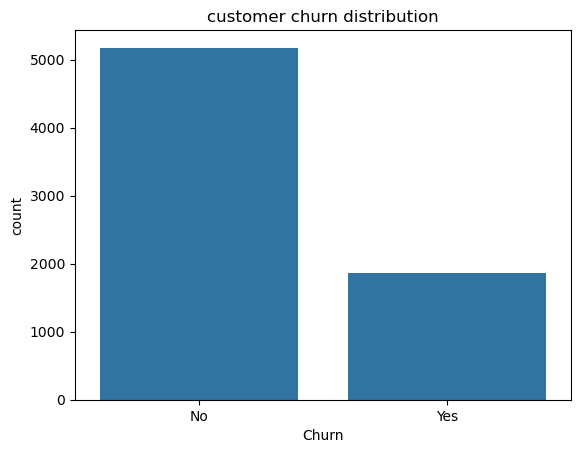

In [17]:
sns.countplot(x='Churn',data=df)
plt.title("customer churn distribution")
plt.show()

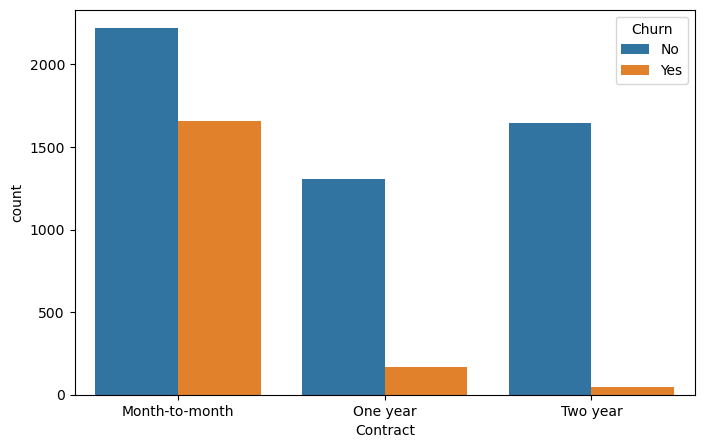

In [18]:
#contract versus churn 
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data= df
)
plt.show()

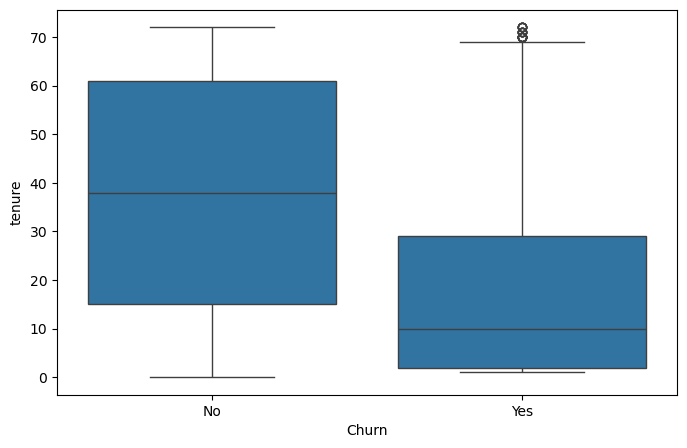

In [20]:
# TENURE ANALYSIS
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.show()

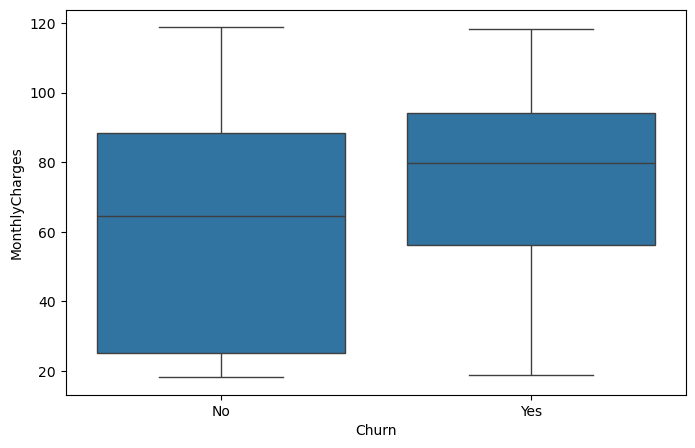

In [21]:
# MONTHLY CHARGE ANALYSIS

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)
plt.show()

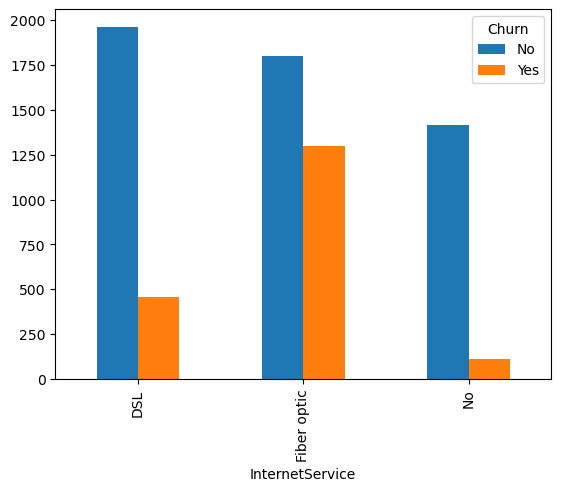

In [22]:
#CHURN BY INTERENT SERVICE
pd.crosstab(
    df["InternetService"],
    df["Churn"]
).plot(kind="bar")

plt.show()

In [23]:
df.drop("customerID", axis=1, inplace=True)

In [24]:
le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = le.fit_transform(df[col])

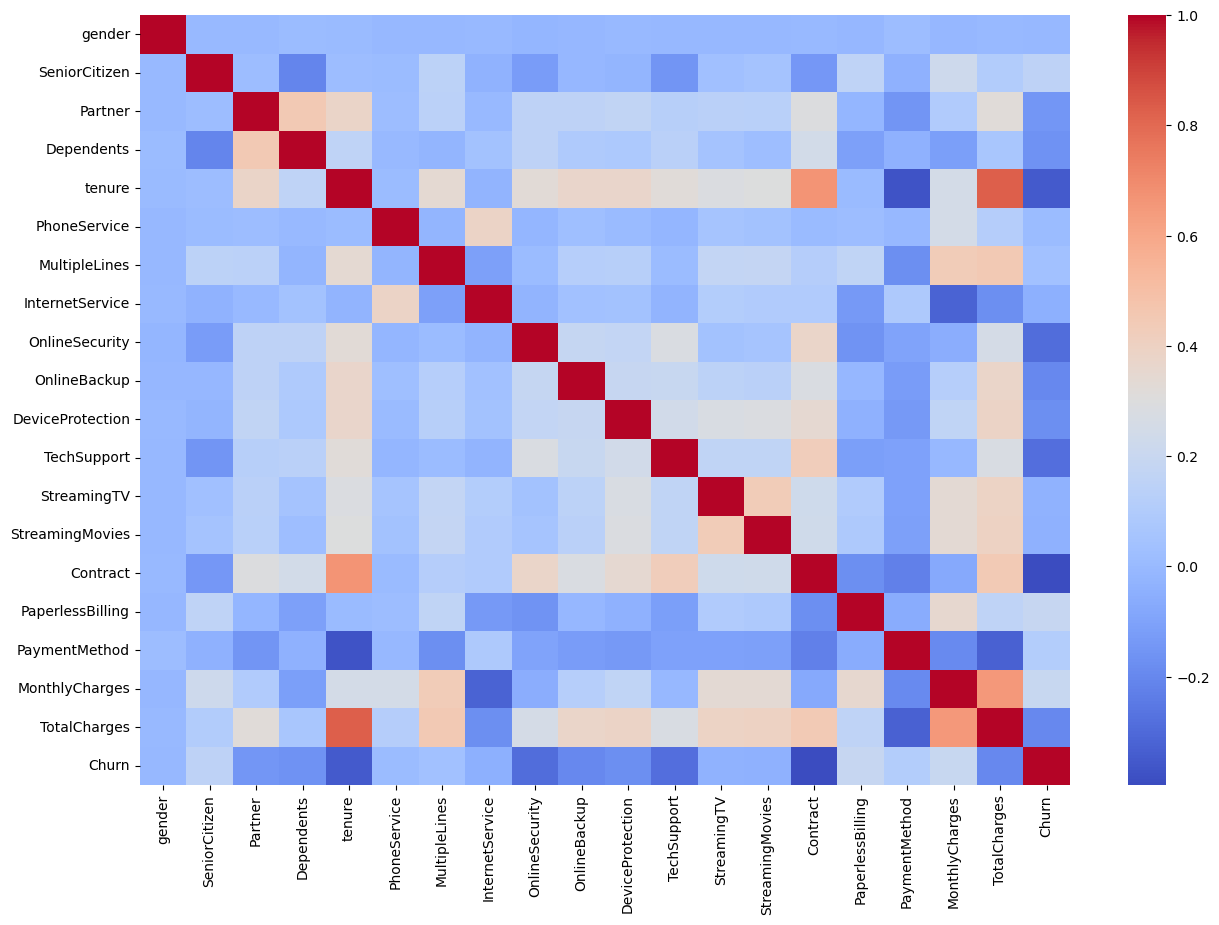

In [25]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [26]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = model.predict(X_test)

In [30]:
accuracy_score(
    y_test,
    y_pred
)

0.7977288857345636

In [31]:
confusion_matrix(
    y_test,
    y_pred
)

array([[949,  87],
       [198, 175]])

In [32]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [33]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob
)

0.8364248967466126

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [35]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.191258
17,MonthlyCharges,0.178396
4,tenure,0.156702
14,Contract,0.077677
16,PaymentMethod,0.050239
8,OnlineSecurity,0.047217
11,TechSupport,0.043595
0,gender,0.027814
9,OnlineBackup,0.027086
7,InternetService,0.026418


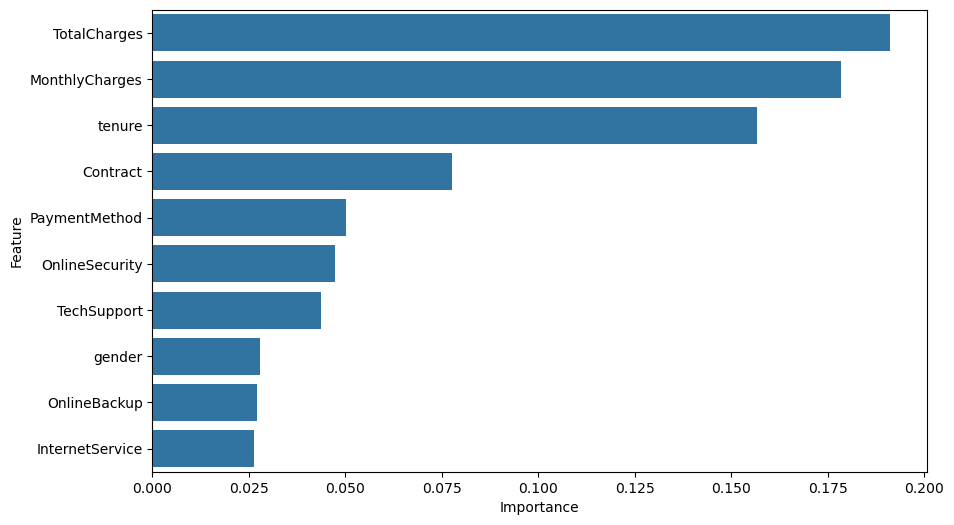

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.show()

In [37]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Probability":
    model.predict_proba(X_test)[:,1]
})

In [38]:
predictions.to_csv(
    "churn_predictions.csv",
    index=False
)